<a href="https://colab.research.google.com/github/lodigasatish-ai/teleconnect-ml-assignment/blob/main/notebooks/04_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Training Linear Regression = 


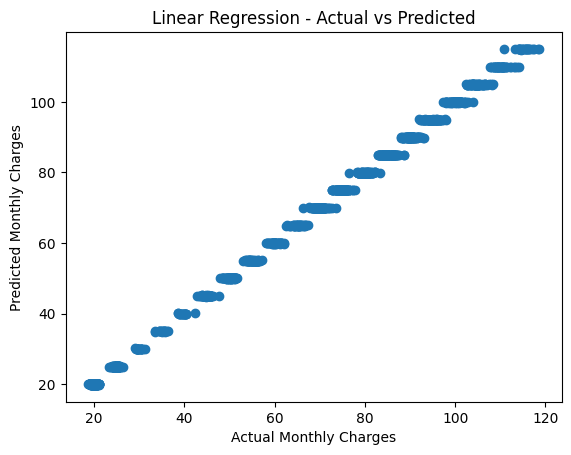


Training Ridge = 


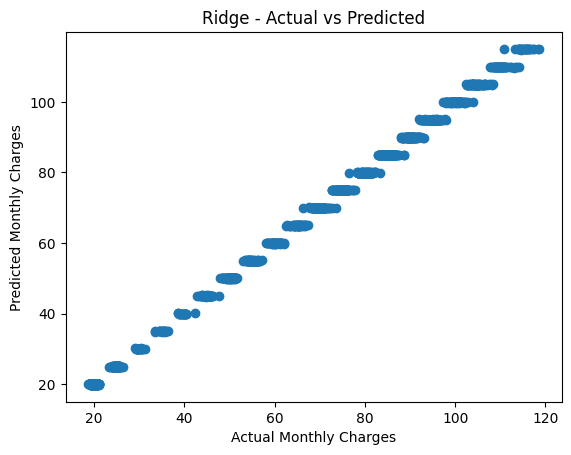


Training Lasso = 


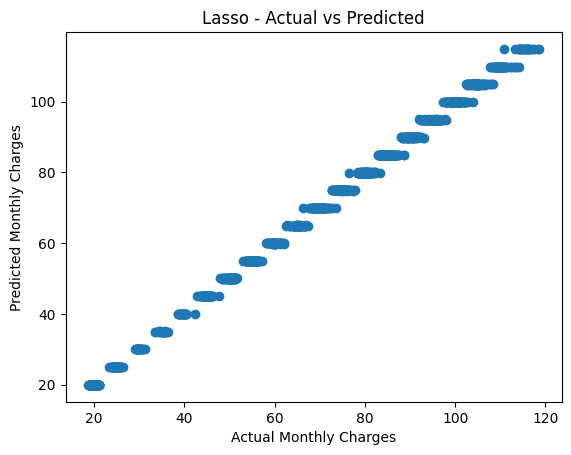


Training ElasticNet = 


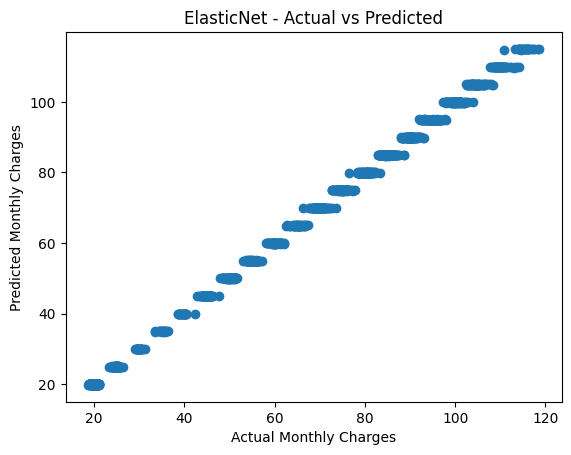


Training Decision Tree = 


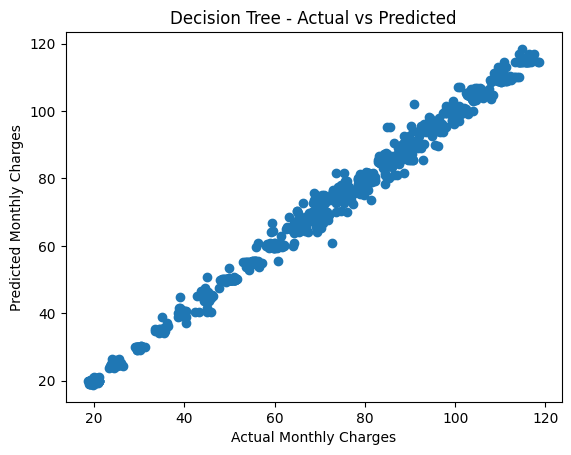


Training Random Forest = 


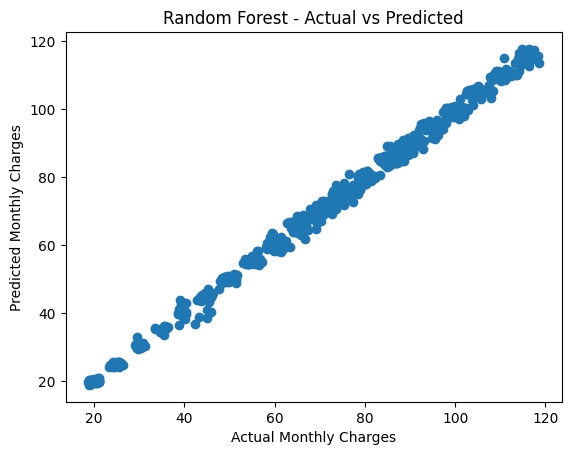


Training SVR = 


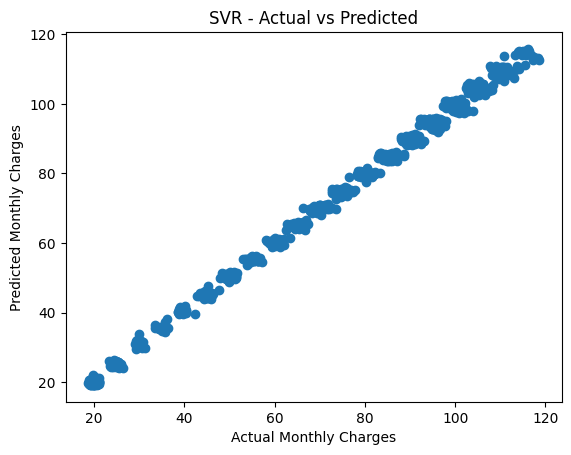


Final Comparison Table:
               Model    MAE    MSE   RMSE     R2  Adj_R2    Time
0  Linear Regression  0.784  1.076  1.037  0.999   0.999   5.079
1              Ridge  0.784  1.076  1.037  0.999   0.999   0.351
2              Lasso  0.781  1.076  1.037  0.999   0.999   2.853
3         ElasticNet  0.782  1.077  1.038  0.999   0.999  19.720
4      Decision Tree  1.131  3.012  1.736  0.997   0.996   0.441
5      Random Forest  0.921  1.691  1.300  0.998   0.998  23.037
6                SVR  0.944  1.629  1.276  0.998   0.998  11.824

Best Model: Linear Regression


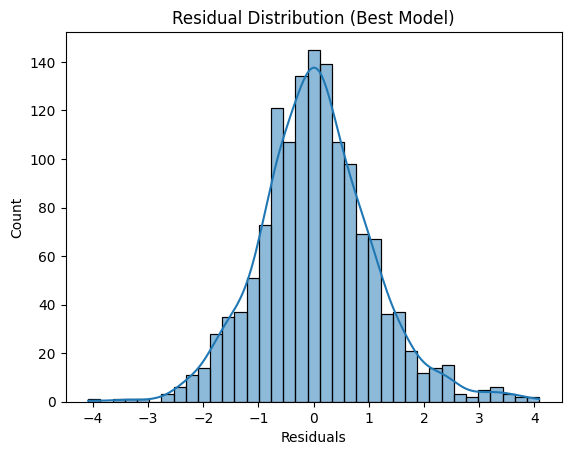

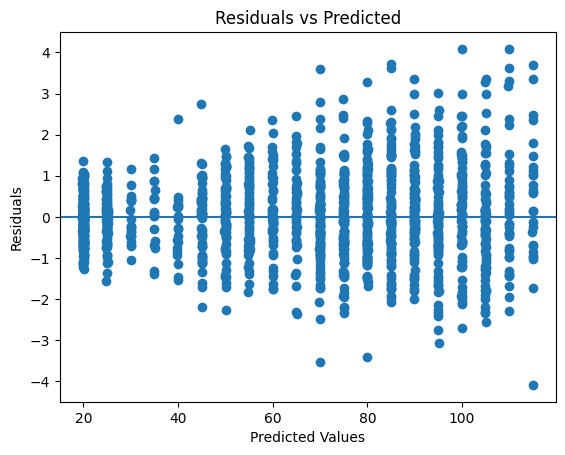


Top Positive Features:
                        Feature  Coefficient
16  InternetService_Fiber optic     6.974768
32              StreamingTV_Yes     3.467302
35          StreamingMovies_Yes     3.466755
23             OnlineBackup_Yes     2.256809
29              TechSupport_Yes     2.255938

Top Negative Features:
                                 Feature  Coefficient
25  DeviceProtection_No internet service    -2.466991
28       TechSupport_No internet service    -2.466991
31       StreamingTV_No internet service    -2.466991
19    OnlineSecurity_No internet service    -2.466991
15                   InternetService_DSL    -5.152551

Task 4 completed successfully.


In [1]:
# Task 4: Regression — Revenue Forecasting
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Load Dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# 2. Preprocessing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop(columns=['customerID'], inplace=True)

le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

df = pd.get_dummies(df)

# Define X and y
X = df.drop("MonthlyCharges", axis=1)
y = df["MonthlyCharges"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 4. Models + Hyperparameters
models = {
    "Linear Regression": (LinearRegression(), {}),

    "Ridge": (Ridge(), {'alpha': [0.1, 1, 10]}),

    "Lasso": (Lasso(max_iter=5000), {'alpha': [0.001, 0.01, 0.1]}),

    "ElasticNet": (
        ElasticNet(max_iter=10000),
        {'alpha': [0.001, 0.01, 0.1], 'l1_ratio': [0.2, 0.5, 0.8]}
    ),

    "Decision Tree": (
        DecisionTreeRegressor(),
        {'max_depth': [5, 10, None]}
    ),

    "Random Forest": (
        RandomForestRegressor(random_state=42),
        {'n_estimators': [50, 100], 'max_depth': [10, None]}
    ),

    "SVR": (
        SVR(),
        {'C': [0.1, 1], 'kernel': ['rbf']}
    )
}

results = []
best_models = {}

# Training Loop
for name, (model, params) in models.items():
    print(f"\nTraining {name} = ")

    start = time.time()

    grid = GridSearchCV(model, params, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    train_time = time.time() - start

    # Predictions
    y_pred = best_model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Adjusted R²
    n = X_test.shape[0]
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    results.append([name, mae, mse, rmse, r2, adj_r2, train_time])

    # Actual vs Predicted Plot
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Monthly Charges")
    plt.ylabel("Predicted Monthly Charges")
    plt.title(f"{name} - Actual vs Predicted")
    plt.show()

# Results Table
results_df = pd.DataFrame(results, columns=[
    "Model", "MAE", "MSE", "RMSE", "R2", "Adj_R2", "Time"
])

print("\nFinal Comparison Table:")
print(results_df.round(3))

# Best Model Selection
best_name = results_df.sort_values(by="R2", ascending=False).iloc[0]["Model"]
print("\nBest Model:", best_name)

best_model = best_models[best_name]

# Residual Analysis
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

# Histogram
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Best Model)")
plt.xlabel("Residuals")
plt.show()
plt.figure()
plt.scatter(y_pred_best, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# Coefficient Analysis (Linear Models)
if hasattr(best_model, "coef_"):
    coef = best_model.coef_
    features = X.columns

    coef_df = pd.DataFrame({
        "Feature": features,
        "Coefficient": coef
    }).sort_values(by="Coefficient", ascending=False)

    print("\nTop Positive Features:")
    print(coef_df.head(5))

    print("\nTop Negative Features:")
    print(coef_df.tail(5))

else:
    print("\nCoefficient analysis not available for this model")

print("\nTask 4 completed successfully.")